In [1]:
import torch
import torchvision
from torchvision import transforms
from torchvision.transforms import Compose, Normalize, ToTensor
from ViT_CX.ViT_CX import ViT_CX
import utils.utils

import numpy as np
import random

from matplotlib import pyplot as plt
import cv2

import time
import pandas as pd

import rasterio as rio
import json
import pickle

import gc

#root = '/home/a01328525/'
root = 'E:/Experiments/'

In [2]:
import argparse
import os

import torch
import torch.utils.data

import model.transformer
import model.trainer as trainer
import utils.datasets
import utils.utils
import utils.plots as plots
import utils.counting as counting
import torchvision
import numpy as np
import warnings
from matplotlib import pyplot as plt
from model.explainability import inference
from model.explainability import explain_VIT_CX as explain_VIT_CX

import utils.anchors
import cv2

import time
import pandas as pd

from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont
import rasterio as rio
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#folder_maps = root+'Datasets Maps/'
#folder_tiles = root+'Datasets Tiles/'
#folder_save_results = root+'Counting images paper 2/'
folder_trained_models = root+"Datasets_STED/runs_transformers/"

img_size = 224

#zone_name='Zone108_octubre'
#zone_name='Zone102_part1'
#zone_name='Zone108'
#zone_name='Zone3'


## Orthophoto explainability TEST

In [3]:
"""
####### SAVE FRACTION FROM FULL ORTHOMAP #################
map_dir = folder_maps+zone_name+'_full.tif'
with rio.open(map_dir) as img :
    metadata = img.meta
    imgnp = img.read() 
img_frac = imgnp[:,4112:4446, 4448:4784]
metadata['height'] = 336
metadata['width'] = 336

with rio.open("TEST_explainability_orthomap.tif", "w", **metadata) as dest:
    img_frac[0:3,...] = img_frac[0:3,...]/img_frac[0:3,...].max()
    dest.write(img_frac)
"""

'\n####### SAVE FRACTION FROM FULL ORTHOMAP #################\nmap_dir = folder_maps+zone_name+\'_full.tif\'\nwith rio.open(map_dir) as img :\n    metadata = img.meta\n    imgnp = img.read() \nimg_frac = imgnp[:,4112:4446, 4448:4784]\nmetadata[\'height\'] = 336\nmetadata[\'width\'] = 336\n\nwith rio.open("TEST_explainability_orthomap.tif", "w", **metadata) as dest:\n    img_frac[0:3,...] = img_frac[0:3,...]/img_frac[0:3,...].max()\n    dest.write(img_frac)\n'

In [4]:
model_dir = folder_trained_models+"explain_STED_1001_nano_cbbox_bgr_diou_BitNet/best.pt"

#map_dir = folder_maps+zone_name+'_full.tif'
map_dir = "TEST_explainability_orthomap.tif"

imgnp = counting.read_orthomap_full(map_dir)
print(imgnp.shape)
#f = open(root+'zone_parameters.json')
#zone_parameters = json.load(f)
#f.close()
#correctionRGB = zone_parameters[zone_name]['correctionRGB']
#imgnp[:3,...] = imgnp[:3,...]/correctionRGB
imgnp[:3,...] = imgnp[:3,...]/imgnp[:3,...].max()
print("Orthomap full read")

conf_thr = 0.4 #filter scores to consider only predictions with confidence score greater than conf_thr
iou_thr = 0.5#0.15# using diou #0.5
diou_thr = 0.5#0.15# using diou #0.5

Orthomap read at TEST_explainability_orthomap.tif
(10, 336, 336)
Orthomap full read


In [5]:
print(model_dir)
#data, final_result = counting.get_counting_orthomap(folder_maps, zone_name, model_dir, imgnp, 
#                                                    conf_thr, iou_thr, diou_thr, img_size, device, nms=False)
n_model, num_blks, obj, N_channels, channels, loss_type, bitNet = counting.get_model_pars_from_dir(model_dir)

#result = counting.get_boxes_map(model_dir, imgnp, N_channels, n_model, num_blks, loss_type, obj, 
#                                       channels, conf_thr, iou_thr, diou_thr, img_size, device, bitNet, nms)
ch = channels
import model.transformer
model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                     obj = obj, device=device, bitNet=bitNet).to(device)
checkpoint = torch.load(model_dir, map_location=torch.device(device))
if type(checkpoint) == dict:
    model.load_state_dict(checkpoint['model'])
else:
    model.load_state_dict( checkpoint )
print("Model loaded")

n_pars = counting.count_parameters(model)
n_size_mb = counting.model_size(model)

B = imgnp[0,:,:]
G = imgnp[1,:,:]
R = imgnp[2,:,:]
Re = imgnp[3,:,:]
NIR = imgnp[4,:,:]
tar = imgnp[8,:,:]

bg = imgnp[-1,:,:]

#imgnp = imgnp.transpose((1, 2, 0)) # W x H x N channels
#imgnp = imgnp[:,:,channels]

if ch == 'bgr':
    img = cv2.merge((B, G, R))
elif ch == 'multispectral':
    img = cv2.merge((B, G, R, Re, NIR))
elif ch == 'vi':
    VI_N = ['NDCI', 'TSAVI2', 'ARVI']
    channels = (B, G, R, Re, NIR) 
    VI_1 = VI(channels, VI_N[0], ranges=None)
    VI_2 = VI(channels, VI_N[1], ranges=None)
    VI_3 = VI(channels, VI_N[2], ranges=None)
    img = cv2.merge((B, G, R, VI_1, VI_2, VI_3))       
elif ch == 'viShadowAttenuation': #incomplete
    VI_1 = imgnp[5,:,:]
    VI_2 = imgnp[6,:,:]
    VI_3 = imgnp[7,:,:]
    img = cv2.merge((B, G, R, VI_1, VI_2, VI_3))
else:
    print("Error loading map") 

masks_ = imgnp[8, ...]
print(masks_.shape)
print("Map loaded: "+str(imgnp.shape) )
del imgnp

E:/Experiments/Datasets_STED/runs_transformers/explain_STED_1001_nano_cbbox_bgr_diou_BitNet/best.pt
Model loaded
(336, 336)
Map loaded: (10, 336, 336)


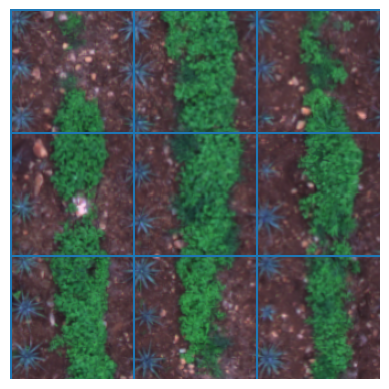

In [6]:
#plt.imshow(img[3200:3536,3100:3436,[2, 1, 0]])
plt.imshow(img[...,[2, 1, 0]])
plt.axis('off')
for i in range(0, 336, 112):
    plt.axvline(i, 0, 1)
for i in range(0, 336, 112):
    plt.axhline(i, 0, 1)
#plt.savefig("test_ortho.png", dpi=300, bbox_inches='tight')

In [7]:
test = img#[3200:3536,3100:3436,:]

In [8]:
explains = []
im_boxes = []
for i in range(0, test.shape[0]-112, img_size//2):
    for j in range(0, test.shape[1]-112, img_size//2):
        i2 = i+img_size if i+img_size < test.shape[0] else test.shape[0]-1
        j2 = j+img_size if j+img_size < test.shape[1] else test.shape[1]-1
        print(i, j)
        #if np.count_nonzero(bg[i:i2,j:j2]==0) > 0.7*224*224: #if more than 70% of image is out of bg continue
        #    continue

        im = np.zeros((img_size, img_size, test.shape[-1]))
        im[0:i2-i, 0:j2-j, :] = test[i:i2,j:j2, :]
        im = (torch.Tensor(im).permute(2, 0, 1).unsqueeze(0)).to(device) #1 x n channels x W x H
        
        mask = np.zeros((img_size, img_size))
        mask[0:i2-i, 0:j2-j] = masks_[i:i2,j:j2]
        mask = (torch.Tensor(mask).unsqueeze(0)).to(device) #1 x n channels x W x H
        
        
        import model.transformer
        model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                             obj = obj, device=device, bitNet=bitNet).to(device)
        checkpoint = torch.load(model_dir, map_location=torch.device(device))
        if type(checkpoint) == dict:
            model.load_state_dict(checkpoint['model'])
        else:
            model.load_state_dict( checkpoint )
        #print("Model loaded")

        boxes, scores, tokens, adjusts, masks  = inference(model, im, obj, conf_thr, diou_thr, adjust_ij=(0, 0), device=device)
        boxes = boxes[0]
        scores = scores[0]
        ###############################################################

        arr = tokens[0].reshape(1, -1).detach().cpu().numpy().squeeze()
        if arr.ndim > 0:
            toks = arr.tolist() 
        else: 
            toks = [int(arr)]

        ############ PLOT BOXES FOR EACH TILE ##################
        cmap = np.array(plt.colormaps.get_cmap('Paired').colors)
        cmap_rgb: list = np.multiply(cmap, 255).astype(np.int32).tolist()
        color = tuple(cmap_rgb[int(0) % len(cmap_rgb)])
        
        img_draw = im[0, ...].permute(1, 2, 0).cpu().clone()
        #img = img[:,:,channels]
        img_draw = img_draw[:,:,[2, 1, 0]]
        img_draw = np.asarray(img_draw)
        img_draw = (255*img_draw/img_draw.max()).astype('uint8')
        #print(img.shape)
        img_draw = Image.fromarray(img_draw)
        draw = ImageDraw.Draw(img_draw)

        print(len(boxes))
        for k in range(len(boxes)):
            xc, yc, r = boxes[k][0], boxes[k][1], boxes[k][2]
            #print(xc, yc, r)
            #cv2.circle(img, (int(pred_boxes_test[i][0]), int(pred_boxes_test[i][1])), int(pred_boxes_test[i][2]), (255, 0, 0), 2)
            draw.ellipse((xc-r, yc-r, xc+r, yc+r), outline=color, width=2)
        
            # label
            text = '{} {:.1f}'.format(" ", scores[k] * 100)
            font = ImageFont.truetype('calibri.ttf', size=12)
            text_width, text_height = font.getbbox(text)[-2:]
            draw.rectangle(((xc, yc), (xc + text_width, yc + text_height)), fill=color)
            draw.text((xc, yc), text, fill=(0, 0, 0), font=font)

        im_boxes.append(img_draw)
        results = explain_VIT_CX(model_dir, im, toks)
        explains.append(results)

0 0
11
0 112
13
112 0
11
112 112
10


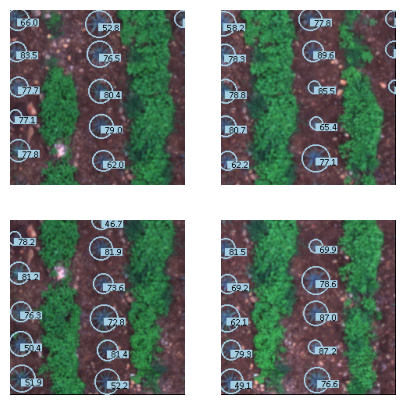

In [9]:
plt.figure(figsize=(5, 5))
plt.subplot(2, 2, 1)
plt.imshow(im_boxes[0]); plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(im_boxes[1]); plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(im_boxes[2]); plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(im_boxes[3]); plt.axis('off')
plt.savefig("test_detection.png", dpi=300, bbox_inches='tight')

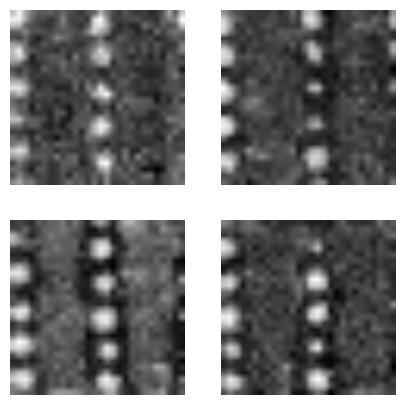

In [10]:
plt.figure(figsize=(5, 5))
plt.subplot(2, 2, 1)
plt.imshow(explains[0], cmap='gray'); plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(explains[1], cmap='gray'); plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(explains[2], cmap='gray'); plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(explains[3], cmap='gray'); plt.axis('off')
plt.savefig("test_explainability.png", dpi=300, bbox_inches='tight')

In [11]:
masks_explains = [[np.asarray(explains[0]), np.asarray(explains[1])], [np.asarray(explains[2]), np.asarray(explains[3])]]

In [12]:
masks_explains[0][1].shape

(224, 224)

In [13]:
import numpy as np

def mad(x):
    med = np.median(x)
    return np.median(np.abs(x - med)) + 1e-6

# global stats
all_vals = np.concatenate([t.ravel() for row in masks_explains for t in row if np.any(t)])
mu_g = np.median(all_vals)
sigma_g = mad(all_vals)


In [14]:
mu_g

np.float32(0.31199223)

In [15]:
np.abs(all_vals - mu_g)

array([0.19582003, 0.19582003, 0.19582003, ..., 0.03598291, 0.03598291,
       0.03598291], shape=(200704,), dtype=float32)

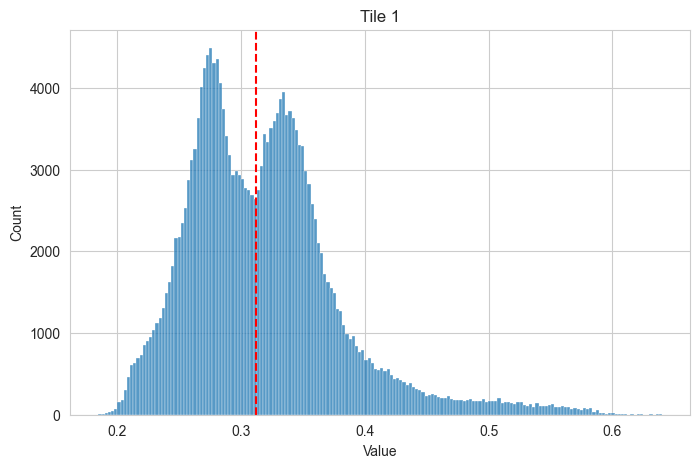

In [16]:
import seaborn as sns

# 2. Set the Seaborn style (optional, but good practice)
sns.set_style("whitegrid")

# 3. Create the histogram
# We use an axes-level function, so we set up the figure and axes first
fig, ax = plt.subplots(figsize=(8, 5))

# Pass the array to the 'x' parameter of histplot
sns.histplot(x=all_vals, ax=ax)

# 4. Add titles and labels (optional)
ax.set_title("Tile 1")
ax.set_xlabel("Value")
#ax.set_ylabel("Frequency")

ax.axvline(mu_g, color='red', linestyle='--', label=f'Median: {mu_g:.2f}')

plt.savefig("test_distribution.png", dpi=300, bbox_inches='tight')

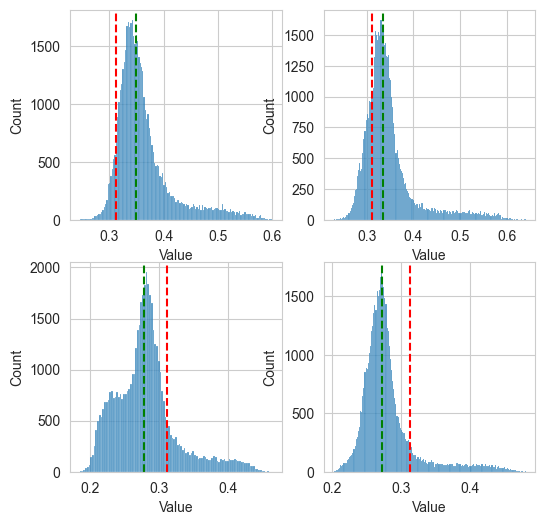

In [17]:
# 2. Set the Seaborn style (optional, but good practice)
sns.set_style("whitegrid")

# 3. Create the histogram
# We use an axes-level function, so we set up the figure and axes first
fig, ax = plt.subplots(2, 2, figsize=(6, 6))

# Pass the array to the 'x' parameter of histplot
sns.histplot(x=masks_explains[0][0].flatten(), ax=ax[0][0])
mu_t = np.median(masks_explains[0][0].flatten())
# 4. Add titles and labels (optional)
#ax[0][0].set_title("Tile 1")
ax[0][0].set_xlabel("Value")
#ax.set_ylabel("Frequency")
ax[0][0].axvline(mu_g, color='red', linestyle='--', label=f'Median: {mu_g:.2f}')
ax[0][0].axvline(mu_t, color='green', linestyle='--', label=f'Median: {mu_g:.2f}')

# Pass the array to the 'x' parameter of histplot
sns.histplot(x=masks_explains[0][1].flatten(), ax=ax[0][1])
mu_t = np.median(masks_explains[0][1].flatten())
# 4. Add titles and labels (optional)
#ax[0][1].set_title("Tile 2")
ax[0][1].set_xlabel("Value")
#ax.set_ylabel("Frequency")
ax[0][1].axvline(mu_g, color='red', linestyle='--', label=f'Median: {mu_g:.2f}')
ax[0][1].axvline(mu_t, color='green', linestyle='--', label=f'Median: {mu_g:.2f}')

# Pass the array to the 'x' parameter of histplot
sns.histplot(x=masks_explains[1][0].flatten(), ax=ax[1][0])
mu_t = np.median(masks_explains[1][0].flatten())
# 4. Add titles and labels (optional)
#ax[1][0].set_title("Tile 3")
ax[1][0].set_xlabel("Value")
#ax.set_ylabel("Frequency")
ax[1][0].axvline(mu_g, color='red', linestyle='--', label=f'Median: {mu_g:.2f}')
ax[1][0].axvline(mu_t, color='green', linestyle='--', label=f'Median: {mu_g:.2f}')

# Pass the array to the 'x' parameter of histplot
sns.histplot(x=masks_explains[1][1].flatten(), ax=ax[1][1])
mu_t = np.median(masks_explains[1][1].flatten())
# 4. Add titles and labels (optional)
#ax[1][1].set_title("Tile 4")
ax[1][1].set_xlabel("Value")
#ax.set_ylabel("Frequency")
ax[1][1].axvline(mu_g, color='red', linestyle='--', label=f'Median: {mu_g:.2f}')
ax[1][1].axvline(mu_t, color='green', linestyle='--', label=f'Median: {mu_g:.2f}')

plt.savefig("test_histos.png", dpi=300, bbox_inches='tight')

In [18]:
def shift_tiles_to_global(tiles, k=1.25, apply_scale=False):
    # global stats
    all_vals = np.concatenate([t.ravel() for row in tiles for t in row if np.any(t)])
    mu_g = np.median(all_vals)
    sigma_g = mad(all_vals)

    out = []
    for row in tiles:
        row_out = []
        for t in row:
            if not np.any(t):
                row_out.append(t)
                continue

            mu_t = np.median(t[t != 0])
            sigma_t = mad(t[t != 0])

            # --- shift only ---
            delta = np.clip(mu_g - mu_t, -k*sigma_g, k*sigma_g)
            t_shifted = t + delta

            # --- optional mild scale ---
            if apply_scale:
                scale = np.sqrt(sigma_g / (sigma_t + 1e-6))
                scale = np.clip(scale, 0.85, 1.2)
                t_shifted *= scale

            row_out.append(t_shifted)

        out.append(row_out)

    return out

In [19]:
masks_explains2 = shift_tiles_to_global(masks_explains, k=1.5)

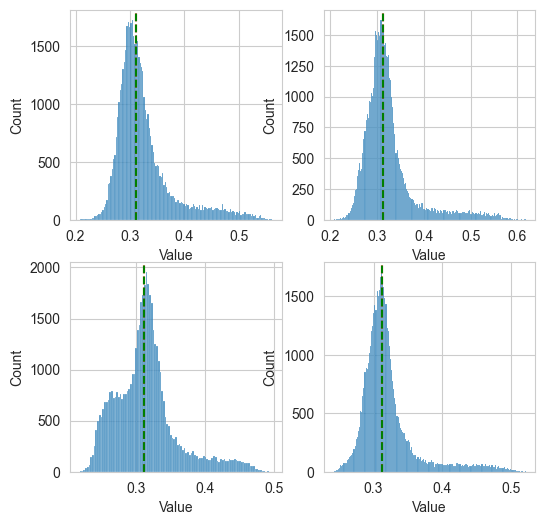

In [20]:
# 2. Set the Seaborn style (optional, but good practice)
#sns.set_style("whitegrid")

# 3. Create the histogram
# We use an axes-level function, so we set up the figure and axes first
fig, ax = plt.subplots(2, 2, figsize=(6, 6))

# Pass the array to the 'x' parameter of histplot
sns.histplot(x=masks_explains2[0][0].flatten(), ax=ax[0][0])
mu_t = np.median(masks_explains2[0][0].flatten())
# 4. Add titles and labels (optional)
#ax[0][0].set_title("Tile 1")
ax[0][0].set_xlabel("Value")
#ax.set_ylabel("Frequency")
ax[0][0].axvline(mu_g, color='red', linestyle='--', label=f'Median: {mu_g:.2f}')
ax[0][0].axvline(mu_t, color='green', linestyle='--', label=f'Median: {mu_g:.2f}')

# Pass the array to the 'x' parameter of histplot
sns.histplot(x=masks_explains2[0][1].flatten(), ax=ax[0][1])
mu_t = np.median(masks_explains2[0][1].flatten())
# 4. Add titles and labels (optional)
#ax[0][1].set_title("Tile 2")
ax[0][1].set_xlabel("Value")
#ax.set_ylabel("Frequency")
ax[0][1].axvline(mu_g, color='red', linestyle='--', label=f'Median: {mu_g:.2f}')
ax[0][1].axvline(mu_t, color='green', linestyle='--', label=f'Median: {mu_g:.2f}')

# Pass the array to the 'x' parameter of histplot
sns.histplot(x=masks_explains2[1][0].flatten(), ax=ax[1][0])
mu_t = np.median(masks_explains2[1][0].flatten())
# 4. Add titles and labels (optional)
#ax[1][0].set_title("Tile 3")
ax[1][0].set_xlabel("Value")
#ax.set_ylabel("Frequency")
ax[1][0].axvline(mu_g, color='red', linestyle='--', label=f'Median: {mu_g:.2f}')
ax[1][0].axvline(mu_t, color='green', linestyle='--', label=f'Median: {mu_g:.2f}')

# Pass the array to the 'x' parameter of histplot
sns.histplot(x=masks_explains2[1][1].flatten(), ax=ax[1][1])
mu_t = np.median(masks_explains2[1][1].flatten())
# 4. Add titles and labels (optional)
#ax[1][1].set_title("Tile 4")
ax[1][1].set_xlabel("Value")
#ax.set_ylabel("Frequency")
ax[1][1].axvline(mu_g, color='red', linestyle='--', label=f'Median: {mu_g:.2f}')
ax[1][1].axvline(mu_t, color='green', linestyle='--', label=f'Median: {mu_g:.2f}')

plt.savefig("test_histos2.png", dpi=300, bbox_inches='tight')

336 336


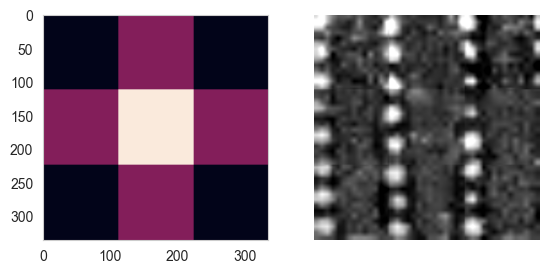

In [21]:
overlap=112
tile_h, tile_w = masks_explains[0][0].shape#224x224
img_h = (len(masks_explains)+1) * (tile_h - overlap) #1*112
img_w = (len(masks_explains[0])+1) * (tile_w - overlap)#3*112
print(img_h, img_w)

merged = np.zeros((img_h, img_w))
weight = np.zeros((img_h, img_w))

for i in range(len(masks_explains)):
    for j in range(len(masks_explains[0])):
        tile1 = masks_explains2[i][j]

        merged[112*i:112*(i+2), 112*j:112*(j+2)] += tile1#(tile1-tile1.min())/(tile1.max()-tile1.min()+1e-10)
        weight[112*i:112*(i+2), 112*j:112*(j+2)] += 1

merged = merged / (weight + 1e-10)
t1_q1, t1_q99 = np.percentile(merged[merged!=0], [1, 99])
merged[merged!=0] = (merged[merged!=0]-t1_q1)/(t1_q99-t1_q1)
merged = np.clip(merged, 0, 1)

plt.subplot(1, 2, 1)
plt.imshow(weight)#; plt.axis('off')
plt.grid(False)
plt.subplot(1, 2, 2)
plt.imshow(merged, cmap='gray'); plt.axis('off')
plt.grid(False)
plt.savefig("test_merging.png", dpi=300, bbox_inches='tight')